In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
# Check for nan values

df.isna().any()

Pregnancies                 False
Glucose                     False
BloodPressure               False
SkinThickness               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool

In [6]:
# Check for label proportions

print("Percentage of labels with no diabetes:", round(len(df[df['Outcome'] == 0]) / len(df) * 100, 2), "%")
print("Percentage of labels with diabetes:", round(len(df[df['Outcome'] == 1]) / len(df) * 100, 2), "%")

Percentage of labels with no diabetes: 65.1 %
Percentage of labels with diabetes: 34.9 %


In [7]:
# Check for the spread of feature values

print(df.drop('Outcome', axis=1).describe().T[['min', 'max', 'mean', 'std']])


                             min     max        mean         std
Pregnancies                0.000   17.00    3.845052    3.369578
Glucose                    0.000  199.00  120.894531   31.972618
BloodPressure              0.000  122.00   69.105469   19.355807
SkinThickness              0.000   99.00   20.536458   15.952218
Insulin                    0.000  846.00   79.799479  115.244002
BMI                        0.000   67.10   31.992578    7.884160
DiabetesPedigreeFunction   0.078    2.42    0.471876    0.331329
Age                       21.000   81.00   33.240885   11.760232


In [ ]:
# std / mean

cv = df.drop('Outcome', axis=1).std() / df.drop('Outcome', axis=1).mean().replace(0, np.nan)
print(cv.sort_values(ascending=False))

Insulin                     1.444170
Pregnancies                 0.876341
SkinThickness               0.776775
DiabetesPedigreeFunction    0.702151
Age                         0.353788
BloodPressure               0.280091
Glucose                     0.264467
BMI                         0.246437
dtype: float64


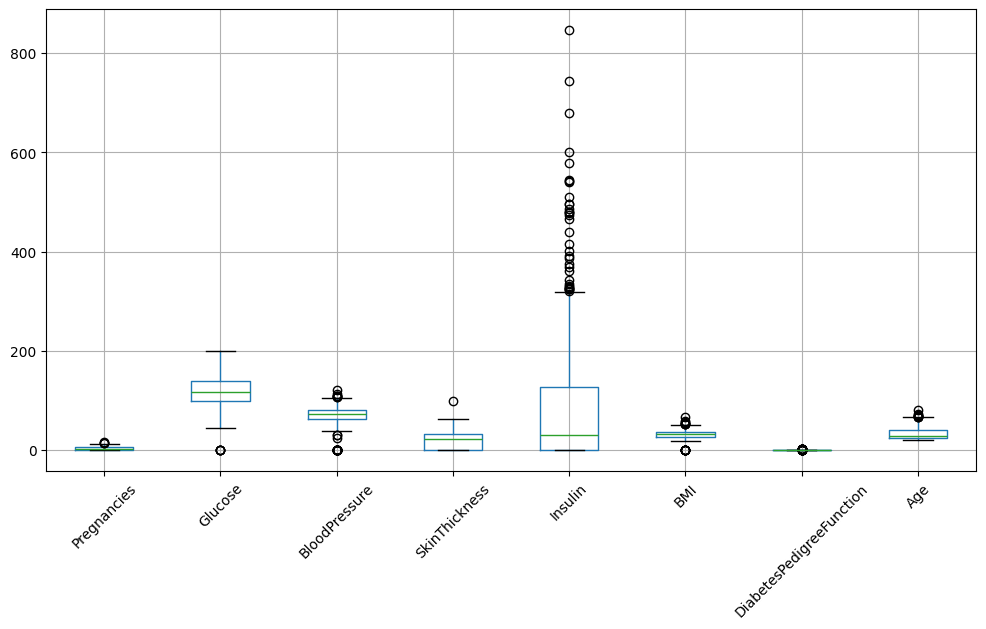

In [9]:
import matplotlib.pyplot as plt

df.drop('Outcome', axis=1).boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Contextual Understanding for potential feature engineering

ChatGPT_5_prompt = """
You are an expert in diabetic diagnosis. Explain briefly for each of the following factors how they may affect diabetes in a straightforward manner, like 'higher XXX -> higher risk of diabetes', and order them in descending influencing power on potential diabetes development.

Number of times pregnant
Plasma glucose concentration a 2 hours in an oral glucose tolerance test
Diastolic blood pressure (mm Hg)
Triceps skin fold thickness (mm)
2-Hour serum insulin (mu U/ml)
Body mass index (weight in kg/(height in m)^2)
Diabetes pedigree function
Age (years)
"""

ChatGPT_5_response = """
1. Plasma glucose concentration (2h OGTT)
Higher 2-hour glucose → much higher chance of diabetes (direct measure of glucose tolerance).

2. Body mass index (BMI)
Higher BMI → higher chance of diabetes due to greater insulin resistance from excess body fat.

3. 2-Hour serum insulin
Higher insulin (with high glucose) → higher chance of diabetes, showing insulin resistance; very low insulin with high glucose → pancreatic dysfunction.

4. Age (years)
Older age → higher chance of diabetes as insulin sensitivity and pancreatic function decline.

5. Diabetes pedigree function
Higher value → higher chance of diabetes due to stronger genetic/family history risk.

6. Number of times pregnant
More pregnancies → higher chance of diabetes, especially if gestational diabetes occurred.

7. Diastolic blood pressure (mm Hg)
Higher blood pressure → higher chance of diabetes as part of metabolic syndrome.

8. Triceps skin fold thickness (mm)
Higher skin fold thickness → higher chance of diabetes due to greater body fat, though less predictive than BMI.
"""